# Implied volatility solver

This notebook runs `implied_vol.py` on a real SPX snapshot. It shows how often Newton-Raphson solves a quote on its own, how often it needs the bisection fallback, and where those fallback cases sit. It uses the sample snapshot committed in `data/snapshots/`, so no internet is needed.

In [1]:
import sys

sys.path.insert(0, "..")  # optionsengine lives one level up, next to notebooks/

import pandas as pd
import matplotlib.pyplot as plt
from optionsengine import config
from optionsengine.quotes import clean_quotes
from optionsengine.validation import add_our_iv, method_distribution

## Load and clean the snapshot

This is one moment of the SPX option chain, pulled live earlier and committed to the repo. `clean_quotes` adds the years to expiry and the forward price, drops quotes with a missing, crossed, or too-wide bid/ask, and keeps only out-of-the-money options: calls above the forward, puts below.

In [2]:
raw = pd.read_csv("../data/snapshots/sample_spx_20260827_1349.csv")
raw["asof"] = pd.to_datetime(raw["asof"])

quotes = clean_quotes(raw, weekly_root=config.ACTIVE.weekly_root,
                       monthly_root=config.ACTIVE.monthly_root,
                       am_hour=config.AM_SETTLEMENT_HOUR, pm_hour=config.PM_SETTLEMENT_HOUR,
                       r=config.r)
print(f"{len(raw)} raw rows -> {len(quotes)} after cleaning")

9902 raw rows -> 5802 after cleaning


## Solve implied volatility

This solves for implied vol once per row. It tries Newton-Raphson first and switches to bisection when Newton's vega check trips.

In [3]:
quotes = add_our_iv(quotes, config.r)

for method, fraction in method_distribution(quotes).items():
    print(f"{method:<10}{fraction:.1%}")

newton    98.3%
bisection 1.7%


## Why bisection happens

Newton solves almost every quote here, starting from a flat 20% guess. It only struggles when vega gets very small. Vega is the slope of price against volatility, and Newton divides by it to pick the next step, so when vega is tiny the step blows up and lands outside the search range. That happens for options with almost no time left and strikes far from the money. Those few quotes fall back to bisection. The plot below shows where they are.

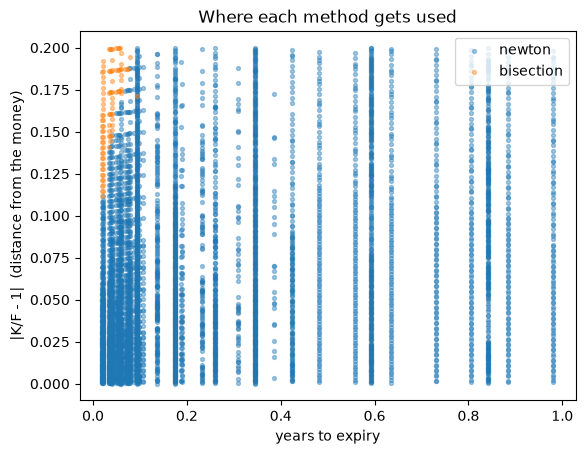

In [4]:
quotes["moneyness_distance"] = (quotes["strike"] / quotes["forward"] - 1).abs()

newton = quotes[quotes["iv_method"] == "newton"]
bisection = quotes[quotes["iv_method"] == "bisection"]

fig, ax = plt.subplots()
ax.scatter(newton["years_to_expiry"], newton["moneyness_distance"], s=8, alpha=0.4, label="newton")
ax.scatter(bisection["years_to_expiry"], bisection["moneyness_distance"], s=8, alpha=0.4, label="bisection")
ax.set_title("Where each method gets used")
ax.set_xlabel("years to expiry")
ax.set_ylabel("|K/F - 1|  (distance from the money)")
ax.legend()
plt.show()

Each point is one solved quote. Newton (blue) handles nearly the whole chain. The bisection cases (orange) sit in a thin band at the bottom right: very little time to expiry and far from the money. That is where vega is small enough to break Newton's step. It is about 2% of the chain.